In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio as rio
import rasterio.plot as rplt
import cmocean as cmo
import xarray as xr

In [2]:
path = r"D:\PhD\21_Experiments\TidesDamageDriver\01_raw\lai2020_vulnerability\vulnerable.nc"
path2 = r"D:\PhD\21_Experiments\TidesDamageDriver\01_raw\lai2020_vulnerability\vulnerable_data2.nc"

lai = xr.open_dataset(path2)
da = lai["vulnerable"]

In [3]:
da = da.rio.write_crs("EPSG:3031", inplace=True)
lai_raster = da.values  # 2D NumPy array
lai_transform = da.rio.transform()  # Affine transform from xarray

In [4]:
res = np.unique_counts(lai_raster)

In [5]:
res.counts

array([ 410993, 1109108,       1, ...,       1,       1,       1],
      shape=(28740902,))

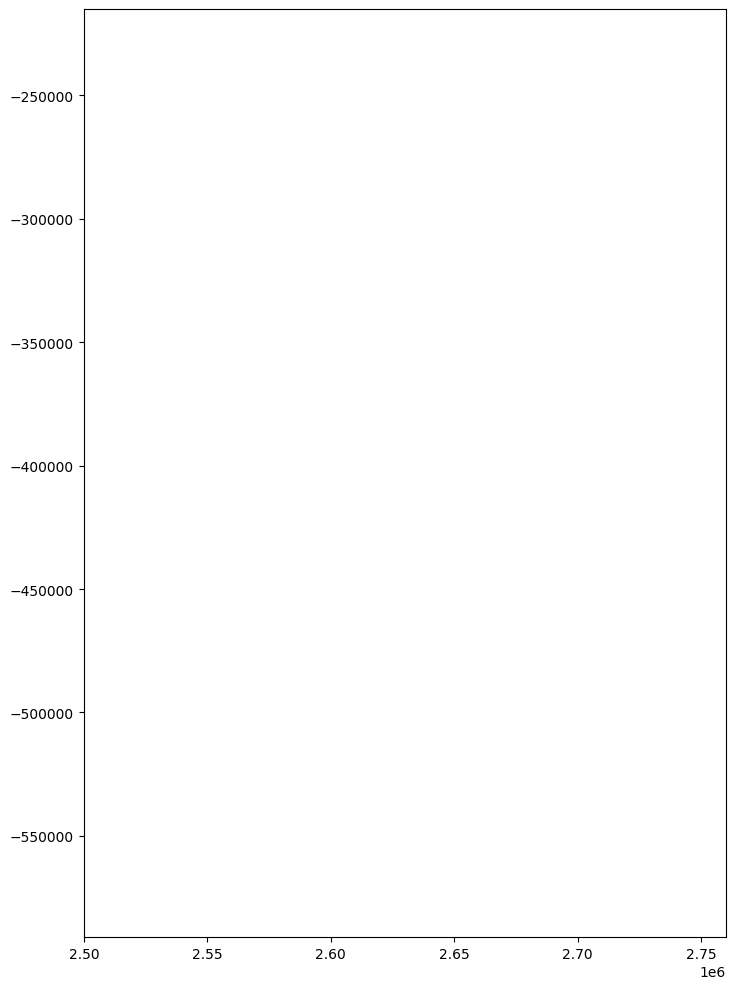

In [6]:
xmin = 2.50e6
xmax = 2.76e6
ymax = -0.215e6
ymin = -0.591e6

fig, ax = plt.subplots(figsize=(10, 10))
rplt.show(lai_raster, ax=ax, transform=lai_transform)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
plt.tight_layout()